In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import _tree
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances

In [2]:
def tree_to_code(tree, feature_names):                    # code from StackOverFlow by paulkernfeld
    tree_ = tree.tree_                                    # convert tree object to portable code to use anywhere
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    print("def tree({}):".format(", ".join(feature_names)))

    def recurse(node, depth):
        indent = "  " * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            print("{}if {} <= {}:".format(indent, name, threshold))
            recurse(tree_.children_left[node], depth + 1)
            print("{}elif {} > {}".format(indent, name, threshold))
            recurse(tree_.children_right[node], depth + 1)
        else:
            print("{}return {}".format(indent, tree_.value[node]))
    recurse(0, 1) 

In [3]:
data = pd.read_excel('R3_ALL.xlsx')

In [4]:
X_cord = data['X'].values
Y_cord = data['Y'].values

# Reshape X_cord and Y_cord to have a shape of (n_samples, 1)
X_cord = X_cord.reshape(-1, 1)
Y_cord = Y_cord.reshape(-1, 1)

# Concatenate X_cord and Y_cord to create a 2D array of shape (n_samples, 2)
points = np.concatenate((X_cord, Y_cord), axis=1)

# Initialize an empty array to store the weights
weights = np.zeros(len(data))

# Iterate over each point in the dataset
for i in range(len(data)):
    # Select the coordinates of the current point
    center_point = points[i]

    # Calculate the displacement lengths between the current point and all other points
    distances = euclidean_distances(points, [center_point])

    # Get the indices of the 10 closest points to the current point
    closest_indices = np.argsort(distances.flatten())[1:11]  # Exclude the center point itself

    # Calculate the weights based on the displacement lengths
    point_weights = 1 / distances[closest_indices]

    # Assign the weights to the corresponding indices
    weights[closest_indices] = point_weights.flatten()

# Assign the calculated weights to the 'weights' column in the dataset
data['weights'] = weights

# Save the dataset to the 'R3_ALL.xlsx' file
data.to_excel('R3_ALL.xlsx', index=False)


In [5]:
# Add categorical labels based on thresholds
data['L_Cat'] = pd.cut(data['L'], bins=[0, 10, float('inf')], labels=['Insignificant', '10 m Event'])

In [6]:
pred = data[['TWI', 'S', 'ID', 'DFC']]
res = data['L_Cat']

In [7]:
pred_train, pred_test, res_train, res_test = train_test_split(pred, res, test_size=0.3, random_state=500)
train_weights = data.loc[pred_train.index, 'weights']

In [8]:
# Create an instance of the DecisionTreeClassifier and fit it to the training data
dt_classifier = DecisionTreeClassifier(max_depth=5)
dt_classifier.fit(pred_train, res_train, sample_weight=train_weights)

DecisionTreeClassifier(max_depth=5)

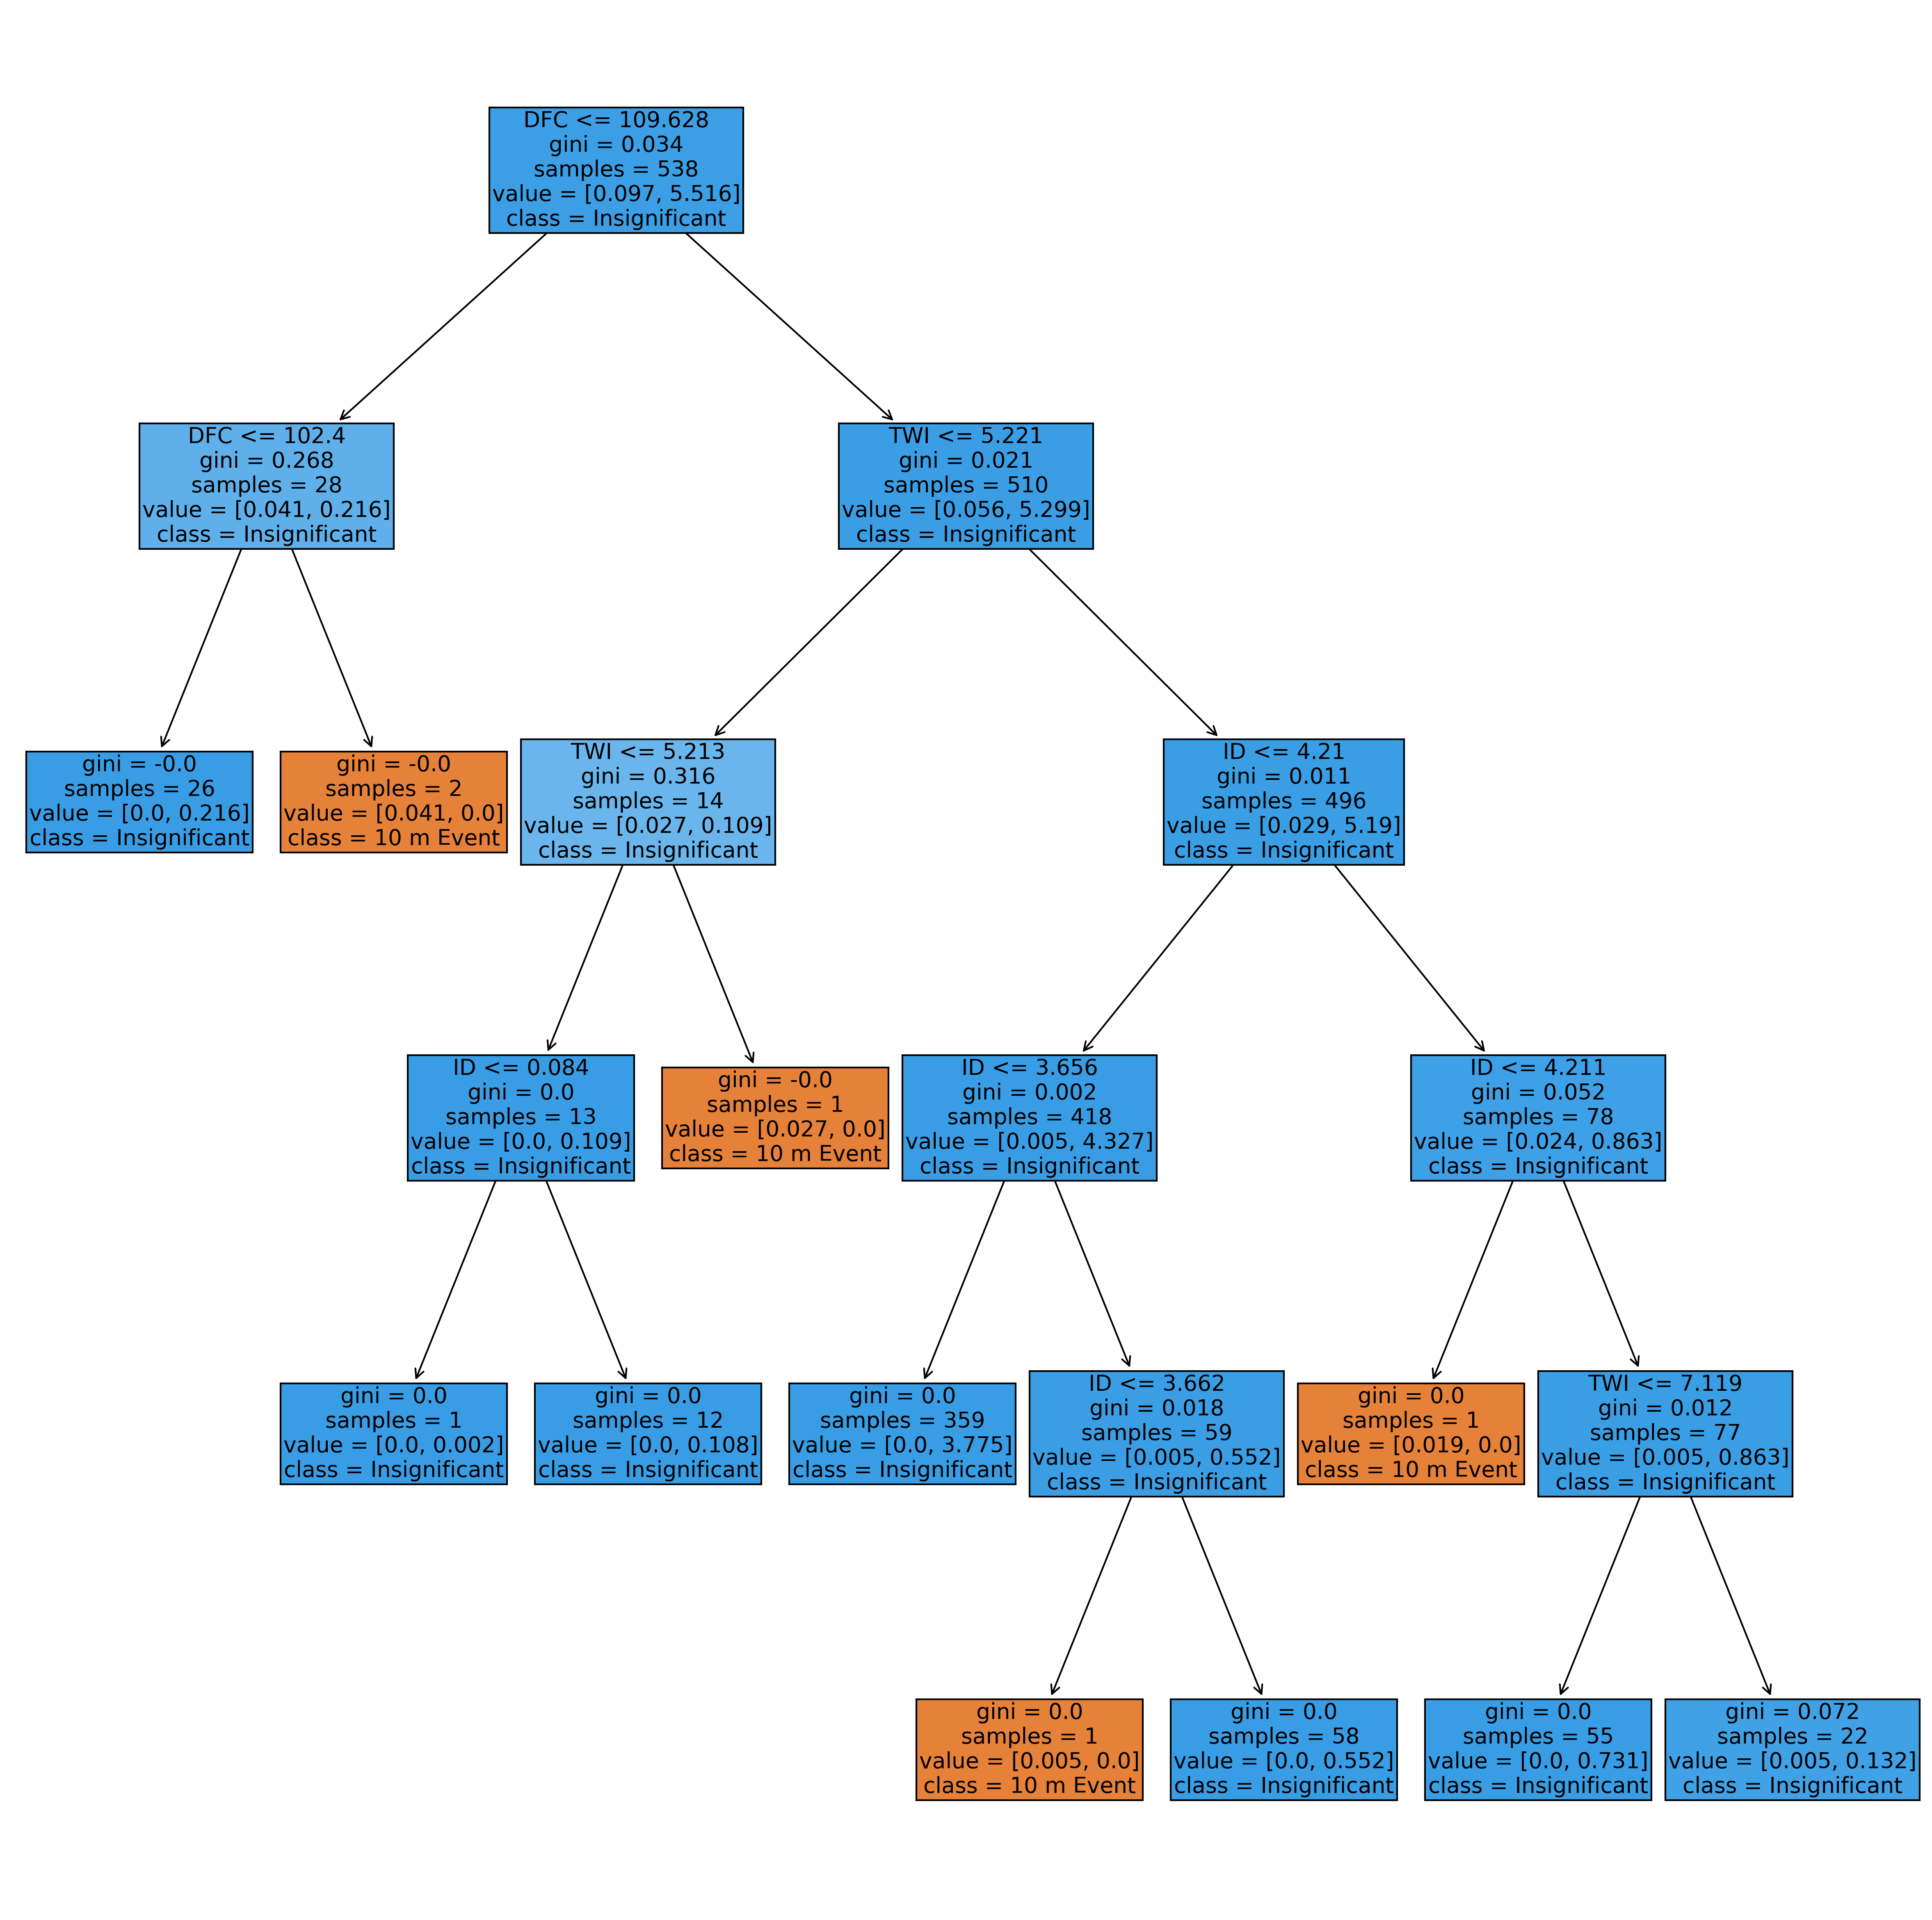

In [9]:
# Visualize the decision tree
plt.figure(figsize=(20, 20), dpi=300)
plt.rcParams.update({'font.size': 30})
plot_tree(dt_classifier, feature_names=pred.columns.tolist(), class_names=list(dt_classifier.classes_), filled=True)
# Save the plot as a PNG image
plt.savefig('R3_decision_tree_10m_Event.png', dpi=1080)
plt.show()


In [10]:
tree_to_code(dt_classifier, list(pred))

def tree(TWI, S, ID, DFC):
  if DFC <= 109.62823867797852:
    if DFC <= 102.3998908996582:
      return [[0.         0.21640342]]
    elif DFC > 102.3998908996582
      return [[0.04104683 0.        ]]
  elif DFC > 109.62823867797852
    if TWI <= 5.22135066986084:
      if TWI <= 5.212693691253662:
        if ID <= 0.08371970057487488:
          return [[0.         0.00170953]]
        elif ID > 0.08371970057487488
          return [[0.         0.10768589]]
      elif TWI > 5.212693691253662
        return [[0.02685078 0.        ]]
    elif TWI > 5.22135066986084
      if ID <= 4.209627628326416:
        if ID <= 3.655894160270691:
          return [[0.         3.77504602]]
        elif ID > 3.655894160270691
          if ID <= 3.6624720096588135:
            return [[0.00515868 0.        ]]
          elif ID > 3.6624720096588135
            return [[0.         0.55179762]]
      elif ID > 4.209627628326416
        if ID <= 4.211217403411865:
          return [[0.0186341 0.       ]]


In [11]:
# Predict the target variable for the test data
res_pred = dt_classifier.predict(pred_test)

In [12]:
# Evaluate the performance of the model by comparing the predicted values with the actual values
accuracy = metrics.accuracy_score(res_test, res_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [13]:
# Calculate evaluation metrics
accuracy = metrics.accuracy_score(res_test, res_pred)
precision = metrics.precision_score(res_test, res_pred, average='weighted')
recall = metrics.recall_score(res_test, res_pred, average='weighted')
f1_score = metrics.f1_score(res_test, res_pred, average='weighted')

# Calculate feature importance
feature_importance = dt_classifier.feature_importances_

# Print the evaluation metrics and feature importance
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)
print("Feature Importance:")
for feature, importance in zip(pred.columns, feature_importance):
    print(feature, ":", importance)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Feature Importance:
TWI : 0.2947800419185045
S : 0.0
ID : 0.26229997944206407
DFC : 0.44291997863943133


In [14]:
# Calculate the range for each predictor feature within each response category
category_ranges = data.groupby('L_Cat')[pred.columns].agg(['min', 'max'])
print("\nRange for each predictor feature within each response category:")
print(category_ranges)


Range for each predictor feature within each response category:
                    TWI                   S                  ID            \
                    min       max       min        max      min       max   
L_Cat                                                                       
Insignificant  4.821588  8.553054  0.281174  11.665916  0.00000  7.299160   
10 m Event     5.219071  7.553831  3.432852   8.218184  2.15418  4.408929   

                      DFC               
                      min          max  
L_Cat                                   
Insignificant   15.068090  2341.262905  
10 m Event     104.531459   489.993296  


In [15]:
# Predict the target variable for the test data
res_pred_ALL = dt_classifier.predict(pred)
data['class'] = res_pred_ALL
data.to_excel('R3_ALL.xlsx', index=False)

In [16]:
accuracy = accuracy_score(res_test, res_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [17]:
confusion = confusion_matrix(res_test, res_pred)
TN = confusion[0, 0]
FP = confusion[0, 1]
FN = confusion[1, 0]
TP = confusion[1, 1]

print("Confusion Matrix:")
print("True Negatives (TN):", TN)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)
print("True Positives (TP):", TP)


IndexError: index 1 is out of bounds for axis 1 with size 1

In [18]:
report = classification_report(res_test, res_pred)
print("Classification Report:")
print(report)

Classification Report:
               precision    recall  f1-score   support

Insignificant       1.00      1.00      1.00       231

     accuracy                           1.00       231
    macro avg       1.00      1.00      1.00       231
 weighted avg       1.00      1.00      1.00       231

